# XIII. web_traffic.csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import math


# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# Định nghĩa đường dẫn dữ liệu (Sửa theo folder của nhóm)
CURRENT_DIR = os.getcwd()
ROOT_DIR = os.path.dirname(CURRENT_DIR)
ROOT_DIR = os.path.dirname(ROOT_DIR)
DATA_RAW_PATH = os.path.join(ROOT_DIR, "data", 'raw')
PROCESSED_PATH = os.path.join(ROOT_DIR, 'data', 'processed')
print(f"Data path: {DATA_RAW_PATH}")

IMAGES_DIR = os.path.join(ROOT_DIR, 'outputs', 'images')
if not os.path.exists(IMAGES_DIR):
    os.makedirs(IMAGES_DIR)

def load_and_clean_data():
    # 1. Load Master Data
    customers = pd.read_csv(os.path.join(DATA_RAW_PATH, 'customers.csv'))
    geography = pd.read_csv(os.path.join(DATA_RAW_PATH, 'geography.csv'))
    inventory = pd.read_csv(os.path.join(DATA_RAW_PATH, 'inventory.csv'))
    products = pd.read_csv(os.path.join(DATA_RAW_PATH, 'products.csv'))
    promotions = pd.read_csv(os.path.join(DATA_RAW_PATH, 'promotions.csv'))

    # 2. Load Transactional / Supporting Data
    orders = pd.read_csv(os.path.join(DATA_RAW_PATH, 'orders.csv'))
    order_items = pd.read_csv(os.path.join(DATA_RAW_PATH, 'order_items.csv'))
    payments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'payments.csv'))
    returns = pd.read_csv(os.path.join(DATA_RAW_PATH, 'returns.csv'))
    reviews = pd.read_csv(os.path.join(DATA_RAW_PATH, 'reviews.csv'))
    sales = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sales.csv'))
    sample_submission = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sample_submission.csv'))
    shipments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'shipments.csv'))
    web_traffic = pd.read_csv(os.path.join(DATA_RAW_PATH, 'web_traffic.csv'))

    # 3. Ép kiểu datetime cho các cột ngày tháng
    dataframes = {
        'customers': customers,
        'inventory': inventory,
        'orders': orders,
        'promotions': promotions,
        'returns': returns,
        'reviews': reviews,
        'sales': sales,
        'sample_submission': sample_submission,
        'shipments': shipments,
        'web_traffic': web_traffic,
    }

    date_cols = {
        'customers': ['signup_date'],
        'inventory': ['snapshot_date'],
        'orders': ['order_date'],
        'promotions': ['start_date', 'end_date'],
        'returns': ['return_date'],
        'reviews': ['review_date'],
        'sales': ['Date'],
        'sample_submission': ['Date'],
        'shipments': ['ship_date', 'delivery_date'],
        'web_traffic': ['date'],
    }

    for df_name, cols in date_cols.items():
        for col in cols:
            if col in dataframes[df_name].columns:
                dataframes[df_name][col] = pd.to_datetime(dataframes[df_name][col], errors='coerce')

    return (
        customers,
        geography,
        inventory,
        orders,
        order_items,
        payments,
        products,
        promotions,
        returns,
        reviews,
        sales,
        sample_submission,
        shipments,
        web_traffic,
    )

(
    customers_df,
    geography_df,
    inventory_df,
    orders_df,
    order_items_df,
    payments_df,
    products_df,
    promotions_df,
    returns_df,
    reviews_df,
    sales_df,
    sample_submission_df,
    shipments_df,
    web_traffic_df,
) = load_and_clean_data()

Data path: d:\University\Competitions\Datathon VinUni\DATATHON-2026-VinUni\data\raw


## 1. Tổng quan

Đã lưu biểu đồ kết hợp tại: d:\University\Competitions\Datathon VinUni\DATATHON-2026-VinUni\outputs\images\web_distribution_boxplot.png


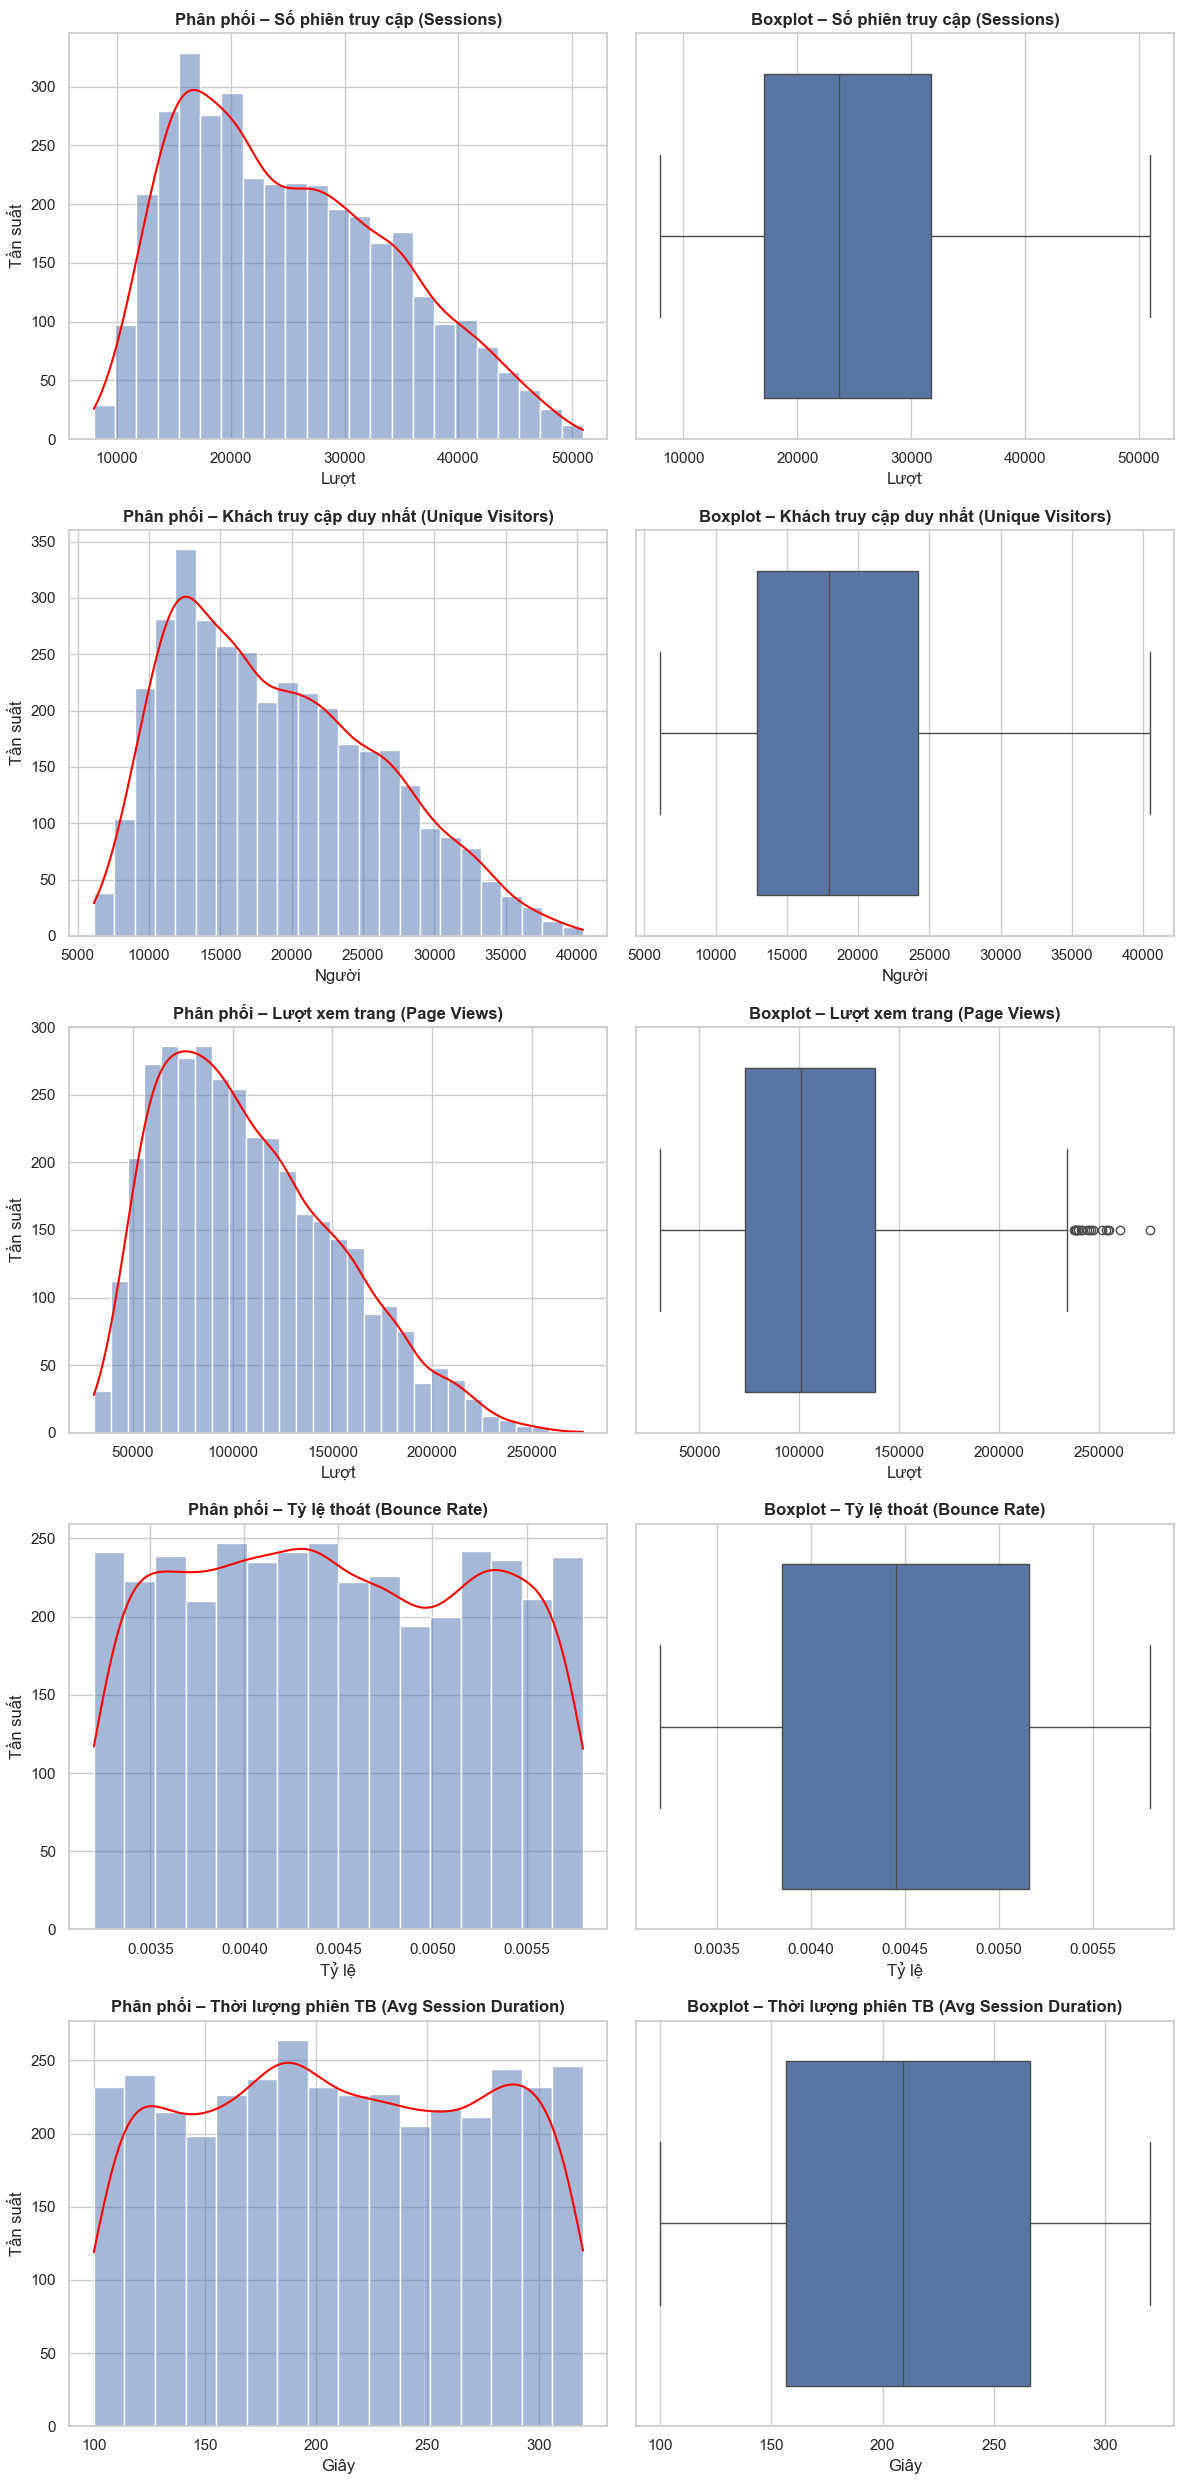

In [7]:
# 2. Cấu hình tiêu đề và nhãn trục X cho các cột số trong web_traffic.csv
col_config = {
    'sessions': {'title': 'Số phiên truy cập (Sessions)', 'xlabel': 'Lượt'},
    'unique_visitors': {'title': 'Khách truy cập duy nhất (Unique Visitors)', 'xlabel': 'Người'},
    'page_views': {'title': 'Lượt xem trang (Page Views)', 'xlabel': 'Lượt'},
    'bounce_rate': {'title': 'Tỷ lệ thoát (Bounce Rate)', 'xlabel': 'Tỷ lệ'},
    'avg_session_duration_sec': {'title': 'Thời lượng phiên TB (Avg Session Duration)', 'xlabel': 'Giây'}
}

# Danh sách các cột định lượng cần vẽ
con_cols_names = ['sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec']

# Hàm vẽ biểu đồ phân phối (Histogram + KDE) có tính năng lưu ảnh
def plot_distribution(df, con_cols_names, save_path=None):
    n = len(con_cols_names)
    
    # Tự động tính số hàng, cột (grid)
    cols = 2  # Đặt 2 biểu đồ trên mỗi hàng cho dễ nhìn
    rows = math.ceil(n / cols)
    
    plt.figure(figsize=(7 * cols, 5 * rows))
    
    for i, col_name in enumerate(con_cols_names, 1):
        cfg = col_config.get(col_name, {'title': col_name, 'xlabel': 'Giá trị'})
        plt.subplot(rows, cols, i)
        sns.histplot(df[col_name].dropna(), kde=True)
        plt.title(f"Phân phối - {cfg['title']}", fontweight='bold')
        plt.xlabel(cfg['xlabel'])
        plt.ylabel("Tần suất")
    
    plt.tight_layout()
    
    # Lưu ảnh nếu có đường dẫn
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Đã lưu biểu đồ phân phối tại: {save_path}")
        
    plt.show()

# Hàm vẽ kết hợp Distribution và Boxplot có tính năng lưu ảnh
def plot_distribution_boxplot(df, con_cols_names, save_path=None):
    n = len(con_cols_names)
    
    plt.figure(figsize=(12, 5 * n))
    
    for i, col_name in enumerate(con_cols_names):
        cfg = col_config.get(col_name, {'title': col_name, 'xlabel': 'Giá trị'})

        # Distribution plot
        plt.subplot(n, 2, i * 2 + 1)
        ax = sns.histplot(df[col_name].dropna(), kde=True)
        # Kiểm tra an toàn trước khi đổi màu đường KDE (phòng trường hợp data lỗi không sinh ra KDE)
        if len(ax.lines) > 0:
            ax.lines[0].set_color('red')
        plt.title(f"Phân phối – {cfg['title']}", fontweight='bold')
        plt.xlabel(cfg['xlabel'])
        plt.ylabel('Tần suất')
        
        # Box plot
        plt.subplot(n, 2, i * 2 + 2)
        sns.boxplot(x=df[col_name].dropna())
        plt.title(f"Boxplot – {cfg['title']}", fontweight='bold')
        plt.xlabel(cfg['xlabel'])
    
    plt.tight_layout()
    
    # Lưu ảnh nếu có đường dẫn
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Đã lưu biểu đồ kết hợp tại: {save_path}")
        
    plt.show()

# 3. Tạo thư mục và gọi hàm
if not os.path.exists(os.path.join(ROOT_DIR, 'outputs', 'images')):
    os.makedirs(os.path.join(ROOT_DIR, 'outputs', 'images'))

# Gọi hàm và truyền tên file muốn lưu
# plot_distribution(web_traffic_df, con_cols_names, save_path=os.path.join('images', 'web_distribution_plot.png'))
plot_distribution_boxplot(web_traffic_df, con_cols_names, save_path=os.path.join(ROOT_DIR, 'outputs', 'images', 'web_distribution_boxplot.png'))

#### b. Thống kê mô tả 

### 1.1.2. Biến phân loại (Categorical)

## 1.2. Phân tích 2 biến

### 1.2.1. Phân tích tương quan

### 1.2.2. Phân tích cross table

### 1.2.3. Phân tích thời gian

## 2. Tiền xử lý

## 3. Phân tích câu hỏi 

### Câu hỏi: Trong web_traffic.csv, nguồn truy cập (traffic_source) nào có tỷ lệ thoát trung bình (bounce_rate) thấp nhất trên tất cả các ngày xuất hiện nguồn đó trong cột traffic_source?

In [ ]:
web_traffic_df.columns

Index(['date', 'sessions', 'unique_visitors', 'page_views', 'bounce_rate',
       'avg_session_duration_sec', 'traffic_source'],
      dtype='object')

Nguồn truy cập có tỷ lệ thoát trung bình thấp nhất là 'email_campaign' với 0.4458%.

Đã lưu biểu đồ tỷ lệ thoát tại: images/avg_bounce_rate_by_source.png


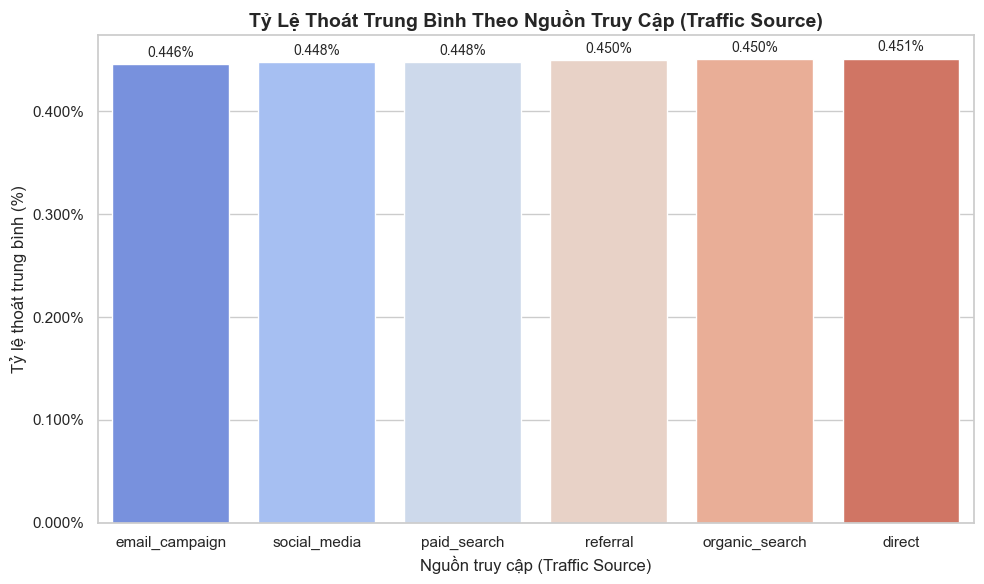

In [ ]:
bounce_rate_by_source = web_traffic_df.groupby('traffic_source')['bounce_rate'].mean().sort_values(ascending=True).reset_index()

# In ra kết quả
lowest_source = bounce_rate_by_source.iloc[0]['traffic_source']
lowest_rate = bounce_rate_by_source.iloc[0]['bounce_rate']
print(f"Nguồn truy cập có tỷ lệ thoát trung bình thấp nhất là '{lowest_source}' với {lowest_rate:.4%}.\n")

# Hàm vẽ biểu đồ thanh so sánh tỷ lệ thoát có tính năng lưu ảnh
def plot_avg_bounce_rate(data, save_path=None):
    plt.figure(figsize=(10, 6))
    
    # Vẽ barplot với seaborn
    ax = sns.barplot(x='traffic_source', y='bounce_rate', data=data, palette='coolwarm')
    
    # Tùy chỉnh tiêu đề và nhãn
    plt.title('Tỷ Lệ Thoát Trung Bình Theo Nguồn Truy Cập (Traffic Source)', fontweight='bold', fontsize=14)
    plt.xlabel('Nguồn truy cập (Traffic Source)', fontsize=12)
    plt.ylabel('Tỷ lệ thoát trung bình (%)', fontsize=12)
    
    # Định dạng trục y hiển thị theo phần trăm (%)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    # Thêm giá trị text trên đỉnh mỗi cột
    for p in ax.patches:
        rate_value = p.get_height()
        ax.annotate(f'{rate_value:.3%}', 
                    (p.get_x() + p.get_width() / 2., rate_value), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points',
                    fontsize=10)

    plt.tight_layout()

    # Lưu ảnh nếu có đường dẫn
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Đã lưu biểu đồ tỷ lệ thoát tại: {save_path}")

    plt.show()

# Tạo thư mục images nếu chưa tồn tại
if not os.path.exists('images'):
    os.makedirs('images')

# Gọi hàm và truyền tên file muốn lưu (hỗ trợ .png, .jpg, .pdf...)
plot_avg_bounce_rate(bounce_rate_by_source, save_path='images/avg_bounce_rate_by_source.png')

### Câu hỏi: Trong customers.csv, xét các khách hàng có age_group khác null, nhóm tuổi nào có số đơn hàng trung bình trên mỗi khách hàng cao nhất? (tổng số đơn / số khách hàng trong nhóm)

Đã lưu biểu đồ tại: images/avg_orders_by_age.png


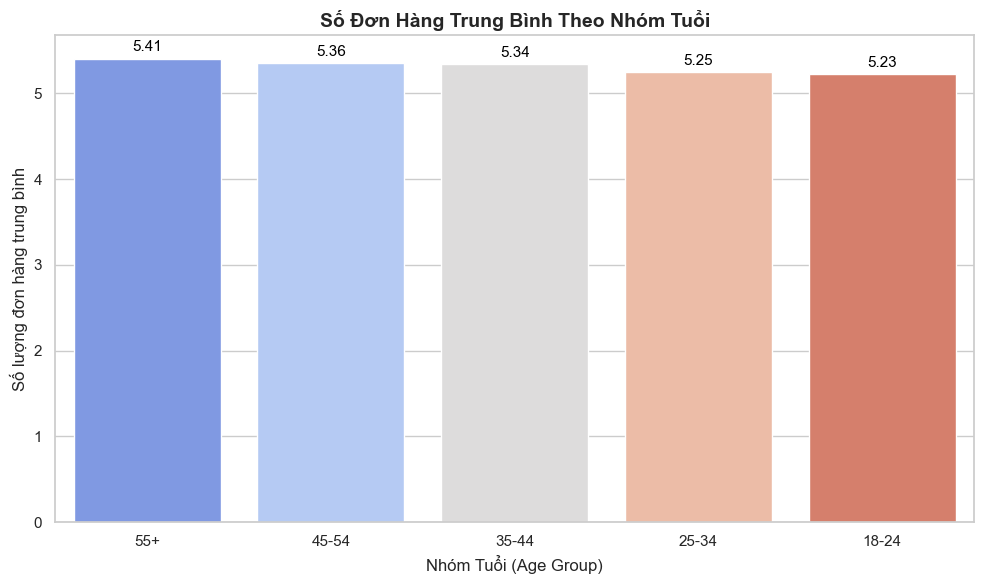

--------------------------------------------------
Kết luận: Nhóm tuổi có số đơn hàng trung bình cao nhất là '55+' với 5.41 đơn/khách hàng.


In [ ]:
customers_df = customers_df.dropna(subset=['age_group'])

# Đếm số lượng đơn hàng của mỗi khách hàng
order_counts = orders_df['customer_id'].value_counts().reset_index()
order_counts.columns = ['customer_id', 'order_count']

# Kết hợp bảng khách hàng với số lượng đơn hàng
merged_df = customers_df.merge(order_counts, on='customer_id', how='left')
# Điền 0 cho những khách hàng chưa có đơn hàng nào
merged_df['order_count'] = merged_df['order_count'].fillna(0) 

# 3. Tính toán theo nhóm tuổi
age_group_stats = merged_df.groupby('age_group').agg(
    total_orders=('order_count', 'sum'),
    total_customers=('customer_id', 'count')
).reset_index()

# Tính số đơn hàng trung bình / khách hàng
age_group_stats['avg_orders'] = age_group_stats['total_orders'] / age_group_stats['total_customers']

# Sắp xếp để biểu đồ đẹp hơn (theo thứ tự giảm dần của avg_orders)
age_group_stats = age_group_stats.sort_values(by='avg_orders', ascending=False)

# Cấu hình biểu đồ
col_config = {
    'avg_orders': {
        'title': 'Số Đơn Hàng Trung Bình Theo Nhóm Tuổi', 
        'xlabel': 'Nhóm Tuổi (Age Group)', 
        'ylabel': 'Số lượng đơn hàng trung bình'
    }
}

# Hàm vẽ biểu đồ cột có tính năng lưu ảnh
def plot_avg_orders_by_age(df, save_path=None):
    plt.figure(figsize=(10, 6))
    
    cfg = col_config['avg_orders']
    
    # Vẽ biểu đồ
    ax = sns.barplot(data=df, x='age_group', y='avg_orders', palette='coolwarm')
    
    plt.title(f"{cfg['title']}", fontweight='bold', fontsize=14)
    plt.xlabel(cfg['xlabel'], fontsize=12)
    plt.ylabel(cfg['ylabel'], fontsize=12)
    
    # Gắn nhãn giá trị trên mỗi cột
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', 
                    fontsize=11, color='black', 
                    xytext=(0, 8), textcoords='offset points')
        
    plt.tight_layout()
    
    # Lưu ảnh
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Đã lưu biểu đồ tại: {save_path}")
        
    plt.show()

# Tạo thư mục lưu ảnh
if not os.path.exists('images'):
    os.makedirs('images')

# Gọi hàm vẽ và lưu ảnh
plot_avg_orders_by_age(age_group_stats, save_path='images/avg_orders_by_age.png')

# In kết luận
best_age_group = age_group_stats.iloc[0]['age_group']
max_avg = age_group_stats.iloc[0]['avg_orders']
print("-" * 50)
print(f"Kết luận: Nhóm tuổi có số đơn hàng trung bình cao nhất là '{best_age_group}' với {max_avg:.2f} đơn/khách hàng.")